# Análisis de la demanda de bicicletas públicas en Seúl

Design & Developed by Nicolas Iglesias


Este proyecto explora como influyen el horario, el clima y la estacionalidad en la cantidad de bicicletas alquiladas en el sistema público de bicicletas de Seúl.

## Objetivo

El objetivo de este análisis es identificar los principales factores asociados a la demanda de bicicletas públicas en Seúl. Para ello, se estudiará la relación entre la cantidad de bicicletas alquiladas y distintas variables temporales y climáticas, como la hora del día, la temperatura, la humedad, la lluvia, la nieve, la estación del año y los feriados.

## Preguntas de análisis

- ¿En que horas del día se alquilan más bicicletas?
- ¿Que estaciones presentan mayor demanda?
- ¿Como afecta la temperatura al uso del sistema?
- ¿La lluvia y la nieve reducen la cantidad de alquileres?
- ¿Existen diferencias entre feriados y dias no feriados?

#### **Librerias a Utilizar**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### **Cargamos el Dataset**

In [5]:
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
df = pd.read_csv("SeoulBikeData.csv",encoding='latin-1')

## **Inspección inicial del dataset**

In [6]:
df.shape

(8760, 14)

In [7]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [9]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


## **Limpieza y preparación de datos**


#### **Nos aseguramos de solo quedarnos con los dias funcionales, para evitar sesgos.**

In [10]:
# Verificamos si existen valores nulos
print("Valores Nulos:\n", df.isnull().sum())

Valores Nulos:
 Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64


In [11]:
# Verificamos si existen duplicados
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


In [12]:
(df["Functioning Day"]=="No").sum()

295

In [13]:
# Copiamos el DataFrame y nos quedamos con los dias funcionales
df_bicis = df[df["Functioning Day"]=="Yes"].copy()

df.shape, df_bicis.shape

((8760, 14), (8465, 14))

In [14]:
(df_bicis["Functioning Day"]=="No").sum()

0

#### **Renombro las columnas**

In [15]:
# Renombro las columnas para facilitar la lectura y el trabajo en Python.
df_bicis = df_bicis.rename(columns={
    'Date': 'fecha',
    'Rented Bike Count': 'bicicletas_alquiladas',
    'Hour': 'hora',
    'Temperature(°C)': 'temperatura',
    'Humidity(%)': 'humedad',
    'Wind speed (m/s)': 'velocidad_viento',
    'Visibility (10m)': 'visibilidad',
    'Dew point temperature(°C)': 'punto_rocio',
    'Solar Radiation (MJ/m2)': 'radiacion_solar',
    'Rainfall(mm)': 'lluvia',
    'Snowfall (cm)': 'nieve',
    'Seasons': 'estacion',
    'Holiday': 'feriado',
    'Functioning Day': 'dia_funcionando'
})
df_bicis.columns

Index(['fecha', 'bicicletas_alquiladas', 'hora', 'temperatura', 'humedad',
       'velocidad_viento', 'visibilidad', 'punto_rocio', 'radiacion_solar',
       'lluvia', 'nieve', 'estacion', 'feriado', 'dia_funcionando'],
      dtype='object')

In [16]:
df_bicis['estacion'].value_counts()

estacion
Summer    2208
Winter    2160
Spring    2160
Autumn    1937
Name: count, dtype: int64

In [17]:
df_bicis['feriado'].value_counts()

feriado
No Holiday    8057
Holiday        408
Name: count, dtype: int64

In [18]:
df_bicis['dia_funcionando'].value_counts()

dia_funcionando
Yes    8465
Name: count, dtype: int64

In [19]:
# Parseo la columna fecha a datetime.
df_bicis['fecha'] = pd.to_datetime(df_bicis['fecha'], format='%d/%m/%Y')

# Verifico que el parseo se haya ejecutado correctamente.
print(df_bicis["fecha"].dtype)

datetime64[ns]


### **Observaciones de limpieza**

En esta etapa se verifica la calidad general de los datos. Se convierte la columna de fecha a formato datetime y se revisa la existencia de valores faltantes, registros duplicados y categorías inconsistentes.

## **Creación de variables derivadas**

In [20]:
df_bicis['mes'] = df_bicis['fecha'].dt.month
df_bicis['dia_semana'] = df_bicis['fecha'].dt.day_name()
df_bicis['fin_de_semana'] = df_bicis['dia_semana'].isin(['Saturday', 'Sunday'])

In [21]:
dias = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

df_bicis['dia_semana'] = df_bicis['fecha'].dt.day_name().map(dias)
df_bicis['fin_de_semana'] = df_bicis['dia_semana'].isin(['Sábado', 'Domingo'])

In [50]:
temporada = {
    'Winter':'Invierno',
    'Spring':'Primavera',
    'Summer':'Verano',
    'Autumn':'Otoño'
}
df_bicis['estacion']=df_bicis['estacion'].map(temporada)

In [53]:
df_bicis['feriado'] = df_bicis['feriado'].map({
    'No Holiday':'No Feriado',
    'Holiday':'Feriado'
})

In [48]:
df_bicis['estacion'].unique()

array(['Invierno', 'Primavera', 'Verano', 'Otoño'], dtype=object)

In [54]:
df_bicis.head()

,fecha,bicicletas_alquiladas,hora,temperatura,humedad,velocidad_viento,visibilidad,punto_rocio,radiacion_solar,lluvia,nieve,estacion,feriado,dia_funcionando,mes,dia_semana,fin_de_semana
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Feriado,Yes,12,Viernes,False
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,NaN,No Feriado,Yes,12,Viernes,False
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,NaN,No Feriado,Yes,12,Viernes,False
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,NaN,No Feriado,Yes,12,Viernes,False
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,NaN,No Feriado,Yes,12,Viernes,False


## **ANÁLISIS EXPLORATORIO**

## **Distribución de la variable objetivo**

In [23]:
df_bicis['bicicletas_alquiladas'].describe()

count    8465.000000
mean      729.156999
std       642.351166
min         2.000000
25%       214.000000
50%       542.000000
75%      1084.000000
max      3556.000000
Name: bicicletas_alquiladas, dtype: float64

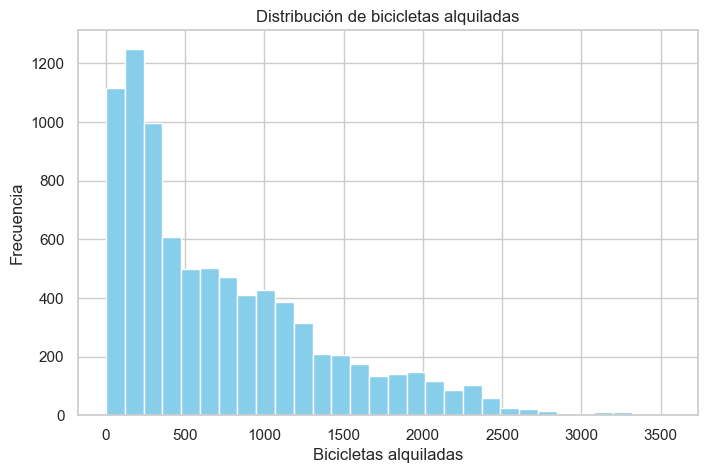

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df_bicis['bicicletas_alquiladas'], color='skyblue', bins=30)
plt.xlabel('Bicicletas alquiladas')
plt.ylabel('Frecuencia')
plt.title('Distribución de bicicletas alquiladas')
plt.show()

In [25]:
# El histograma muestra una distribución sesgada a la derecha en la variable
# 'bicicletas_alquiladas'. La mayor parte de los registros se concentra en
# valores bajos o medios, mientras que hay pocos casos con alquileres muy altos.
# Esto indica una demanda habitual moderada y picos de uso poco frecuentes.

#### **Demanda por hora**

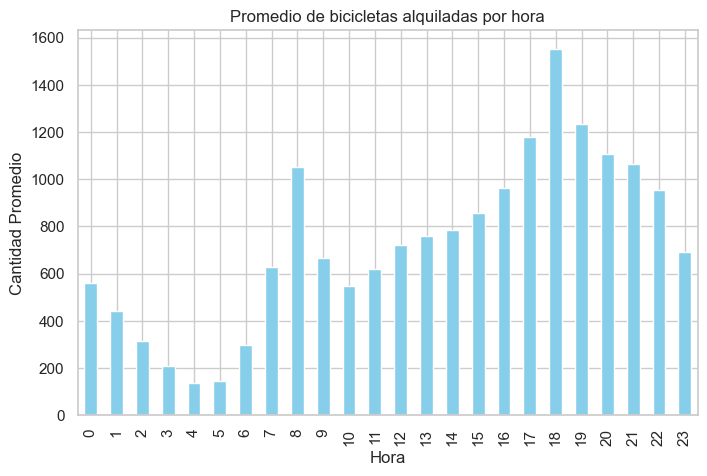

In [39]:
hora_alquilada = df_bicis.groupby("hora")["bicicletas_alquiladas"].mean()

hora_alquilada.plot(kind='bar', color='skyblue', figsize=(8,5))
plt.title("Promedio de bicicletas alquiladas por hora")
plt.xlabel("Hora")
plt.ylabel("Cantidad Promedio")
plt.show()

### Interpretación

El promedio de bicicletas alquiladas por hora muestra un patrón horario definido. La demanda es muy baja durante la madrugada, especialmente entre las 3:00 y las 5:00, y comienza a incrementarse desde las primeras horas de la mañana.

Existe un primer pico a las 8:00, lo que podria indicar un uso asociado a los desplazamientos matutinos. Más adelante, la demanda vuelve a crecer de forma sostenida y alcanza un nuevo pico a las 18:00, horario que podría estar relacionado con los traslados de regreso y otras actividades realizadas al final de la jornada.

En conjunto, este comportamiento indica que el sistema de bicicletas públicas responde fuertemente a patrones de movilidad diaria.

#### **Demanda por estacion**

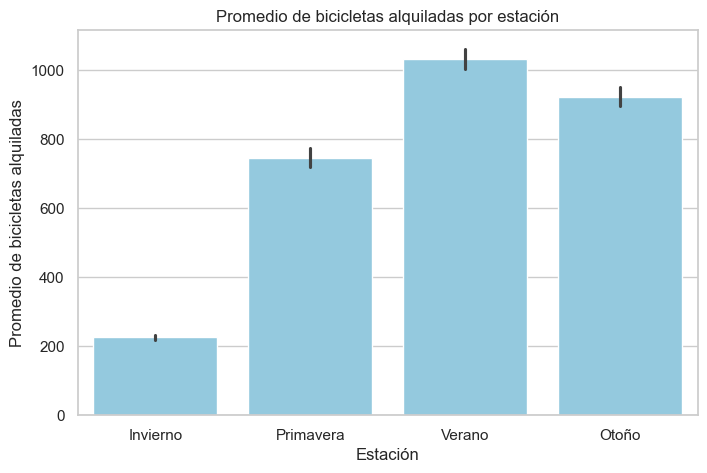

In [49]:
estacion_demanda = df_bicis.groupby("estacion")["bicicletas_alquiladas"].mean().sort_values(ascending = False)

plt.figure(figsize=(8,5))
sns.barplot(data=df_bicis, x='estacion', y='bicicletas_alquiladas', color='skyblue', estimator=np.mean)
plt.title('Promedio de bicicletas alquiladas por estación')
plt.xlabel('Estación')
plt.ylabel('Promedio de bicicletas alquiladas')
plt.show()

### Interpretación

El promedio de bicicletas alquiladas por estación muestra diferencias a lo largo del año. El invierno presenta la demanda más baja de todo el período, mientras que el verano registra el valor promedio más alto. Por su parte, primavera y otoño también muestran niveles elevados de uso, aunque por debajo del verano.

Este patrón indica que la estacionalidad tiene un efecto importante sobre la demanda del sistema. En especial, las estaciones con condiciones climáticas más favorables tienden a concentrar una mayor cantidad de alquileres, mientras que el invierno parece desalentar el uso de la bicicleta como medio de transporte o recreación.

#### **Feriado vs no feriado**

In [28]:
df_bicis['feriado'].value_counts()

feriado
No Holiday    8057
Holiday        408
Name: count, dtype: int64

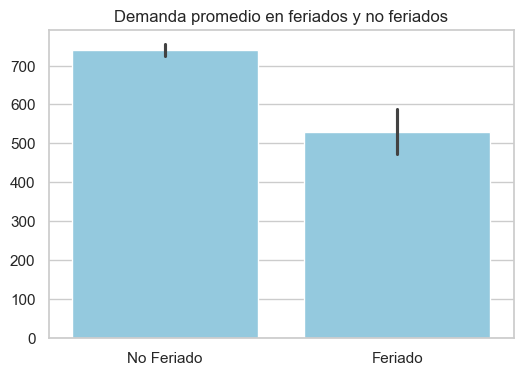

In [59]:
df_bicis.groupby('feriado')['bicicletas_alquiladas'].mean()

plt.figure(figsize=(6,4))
sns.barplot(data=df_bicis, x='feriado', y='bicicletas_alquiladas', color='skyblue', estimator=np.mean)
plt.title('Demanda promedio en feriados y no feriados')
plt.xlabel('')
plt.ylabel('')
plt.show()

### Interpretación

Este resultado puede inidicar que el uso del sistema está vinculado, en parte, a rutinas de movilidad cotidiana. La menor demanda en feriados podría explicarse por una reducción de los desplazamientos habituales, como viajes al trabajo, al estudio o a otras actividades.

#### **Temperatura y Demanda**

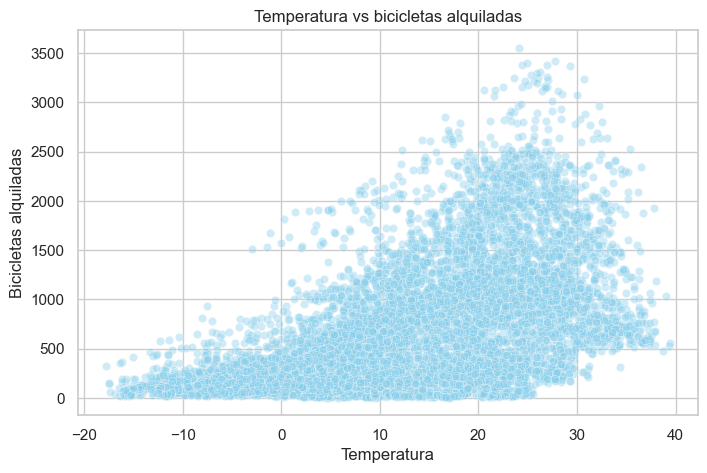

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_bicis, x='temperatura', y='bicicletas_alquiladas', color='skyblue', alpha=0.4)
plt.title('Temperatura vs bicicletas alquiladas')
plt.xlabel('Temperatura')
plt.ylabel('Bicicletas alquiladas')
plt.show()

### Interpretación

El gráfico de dispersión muestra una relación positiva entre la temperatura y la cantidad de bicicletas alquiladas.

La mayor concentración de demandas elevadas aparece en rangos de temperatura moderados a cálidos, lo que indica que condiciones climáticas más favorables incentivan el uso del sistema. Igualmente, la dispersión de los puntos indica que la temperatura no es el único factor relevante y que la demanda también depende de otras variables temporales y climaticas.

#### **Lluvia y demanda**

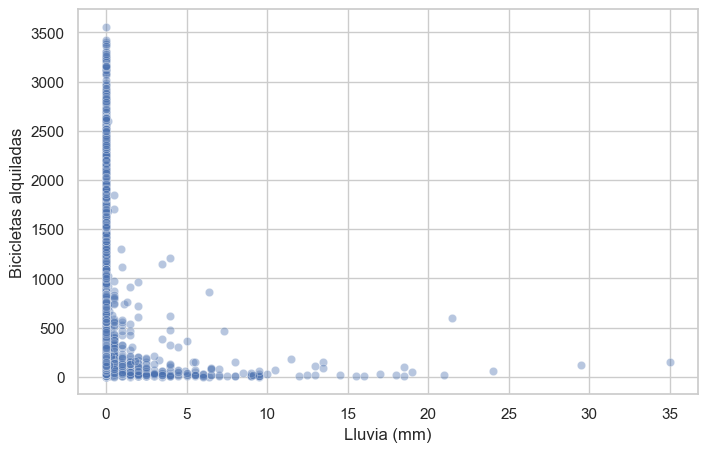

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_bicis, x='lluvia', y='bicicletas_alquiladas', alpha=0.4)
plt.xlabel('Lluvia (mm)')
plt.ylabel('Bicicletas alquiladas')
plt.show()

### Interpretación

El gráfico de dispersión muestra una relacion negativa entre la lluvia y la demanda de bicicletas. Los valores más altos de alquiler se concentran principalmente en observaciones sin precipitaciones (0 mm), mientras que a medida que aumenta la lluvia, la demanda tiende a reducirse.

Aunque la relación no parece estrictamente lineal, el patrón general indica que la presencia de lluvia actua como un factor que desincentiva el uso del sistema.

#### **Nieve y demanda**

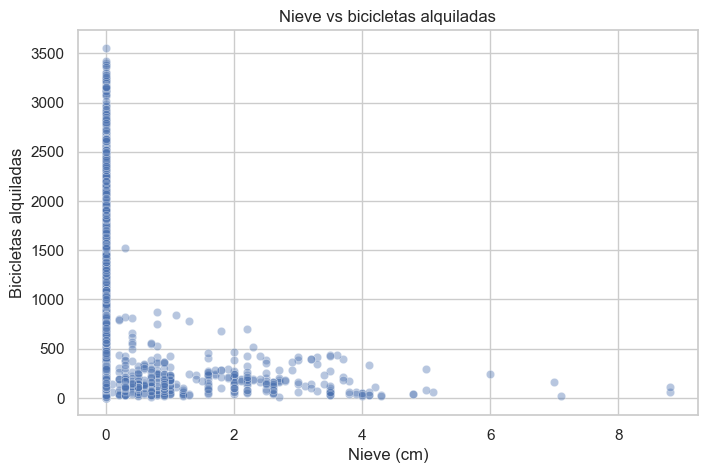

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_bicis, x='nieve', y='bicicletas_alquiladas', alpha=0.4)
plt.title('Nieve vs bicicletas alquiladas')
plt.xlabel('Nieve (cm)')
plt.ylabel('Bicicletas alquiladas')
plt.show()

### Interpretación

En este gráfico de dispersión se observa una relación negativa entre la nieve y la demanda de bicicletas. Los valores más altos de alquiler se concentran principalmente cuando no hay nieve, mientras que a medida que aumenta la acumulación, la demanda tiende a mantenerse en niveles bajos.

Tambien, en comparación con el gráfico de lluvia, la nieve parece mostrar una asociación negativa más marcada con la demanda. Esto podria indicar que las condiciones de nieve podrían desalentar con mayor intensidad el uso del sistema.

#### **Humedad y Demanda**

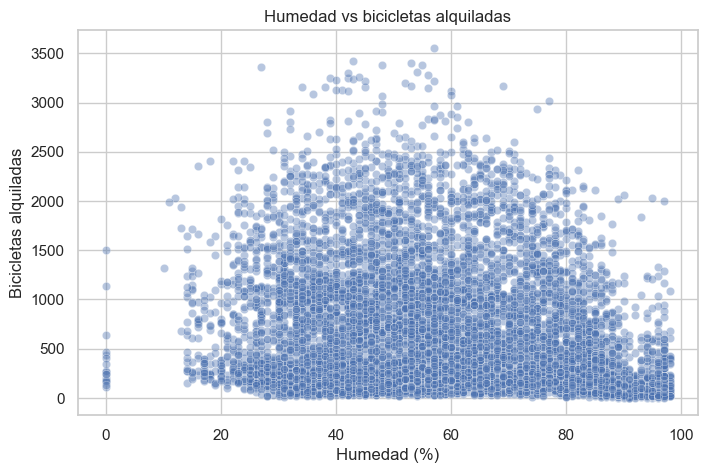

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_bicis, x='humedad', y='bicicletas_alquiladas', alpha=0.4)
plt.title('Humedad vs bicicletas alquiladas')
plt.xlabel('Humedad (%)')
plt.ylabel('Bicicletas alquiladas')
plt.show()

#### **Correlaciones**

In [35]:
cols_numericas = [
    'bicicletas_alquiladas',
    'hora',
    'temperatura',
    'humedad',
    'velocidad_viento',
    'visibilidad',
    'punto_rocio',
    'radiacion_solar',
    'lluvia',
    'nieve'
]

In [36]:
corr = df_bicis[cols_numericas].corr()
corr

,bicicletas_alquiladas,hora,temperatura,humedad,velocidad_viento,visibilidad,punto_rocio,radiacion_solar,lluvia,nieve
bicicletas_alquiladas,1.000000,0.425256,0.562740,-0.201973,0.125022,0.212323,0.400263,0.273862,-0.128626,-0.151611
hora,0.425256,1.000000,0.122742,-0.235937,0.287780,0.103869,0.004691,0.144658,0.014345,-0.022082
temperatura,0.562740,0.122742,1.000000,0.166425,-0.038481,0.028262,0.914467,0.354844,0.052149,-0.217746
humedad,-0.201973,-0.235937,0.166425,1.000000,-0.337352,-0.548542,0.539402,-0.457273,0.236917,0.110127
velocidad_viento,0.125022,0.287780,-0.038481,-0.337352,1.000000,0.180428,-0.177170,0.326222,-0.024931,-0.003789
visibilidad,0.212323,0.103869,0.028262,-0.548542,0.180428,1.000000,-0.182586,0.153046,-0.170352,-0.122860
punto_rocio,0.400263,0.004691,0.914467,0.539402,-0.177170,-0.182586,1.000000,0.098525,0.126812,-0.149760
radiacion_solar,0.273862,0.144658,0.354844,-0.457273,0.326222,0.153046,0.098525,1.000000,-0.074157,-0.073380
lluvia,-0.128626,0.014345,0.052149,0.236917,-0.024931,-0.170352,0.126812,-0.074157,1.000000,0.008604
nieve,-0.151611,-0.022082,-0.217746,0.110127,-0.003789,-0.122860,-0.149760,-0.073380,0.008604,1.000000


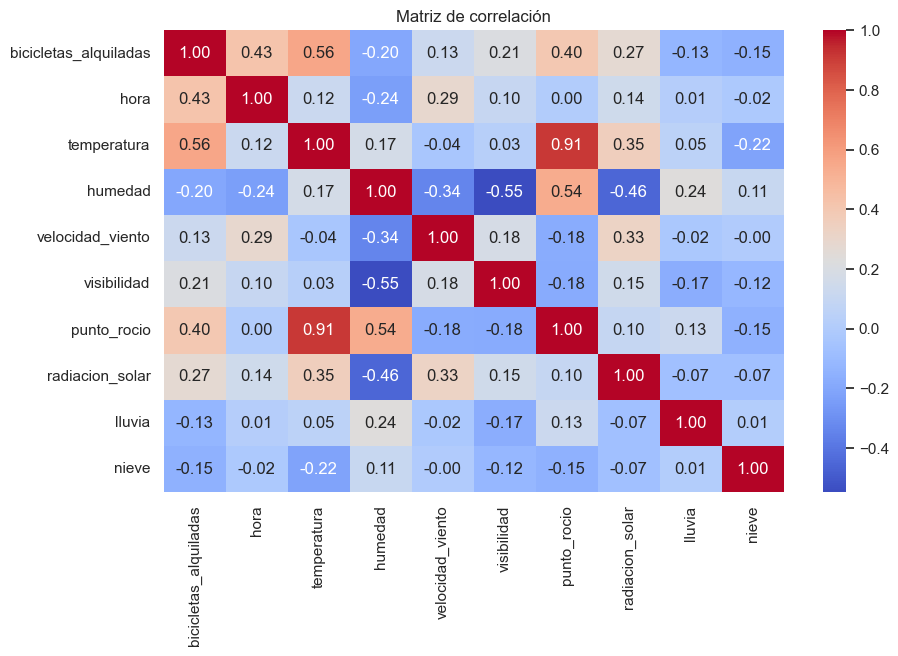

In [37]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

### Interpretación

La matriz de correlación muestra que la temperatura es la variable numérica más asociada con la demanda de bicicletas, con una correlación positiva de 0.56. También se observa una relación positiva importante con la hora (0.43) y con el punto de rocío (0.40), lo que refuerza la idea de que tanto el momento del día como ciertas condiciones climáticas favorables influyen en el uso del sistema.

Por otro lado, la humedad (-0.20), la nieve (-0.15) y la lluvia (-0.13) presentan relaciones negativas con la demanda, aunque su intensidad es relativamente baja. Esto sugiere que estas variables pueden afectar el uso de bicicletas, pero no explican por sí solas gran parte de la variación observada.

Además, se destaca la correlación muy alta entre temperatura y punto de rocío (0.91), lo que indica que ambas variables contienen información muy similar.